# Customer Segmentation Project

In [ ]:
A customer segmentation project to group customers based on their behavior and demographics.

## Objective

The goal of this project is to segment customers into distinct groups based on demographic and behavioral characteristics to support targeted marketing strategies.

## Data Generation and Loading

In [3]:
#Generate dataset

import pandas as pd
import numpy as np

np.random.seed(42)

n_customers = 200

df = pd.DataFrame({
    'CustomerID': range(1, n_customers + 1),
    'Age': np.random.randint(18, 70, n_customers),
    'AnnualIncome': np.random.randint(20000, 120000, n_customers),
    'SpendingScore': np.random.randint(1, 100, n_customers)
})

df.head()

,CustomerID,Age,AnnualIncome,SpendingScore
0,1,56,78053,23
1,2,69,41959,66
2,3,46,25530,27
3,4,32,114856,2
4,5,60,23748,90


In [4]:
#Save dataset

df.to_csv('../data/customer_data.csv', index=False)

## Exploratory Data Analysis (EDA)

In [5]:
# Basic info

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     200 non-null    int64
 1   Age            200 non-null    int64
 2   AnnualIncome   200 non-null    int64
 3   SpendingScore  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


,CustomerID,Age,AnnualIncome,SpendingScore
count,200.000000,200.00000,200.00000,200.000000
mean,100.500000,43.42500,68912.25500,49.670000
std,57.879185,14.94191,29382.16432,29.370636
min,1.000000,18.00000,20301.00000,1.000000
25%,50.750000,31.00000,43269.25000,24.000000
50%,100.500000,43.50000,68379.00000,50.000000
75%,150.250000,56.00000,92768.25000,73.250000
max,200.000000,69.00000,119522.00000,99.000000


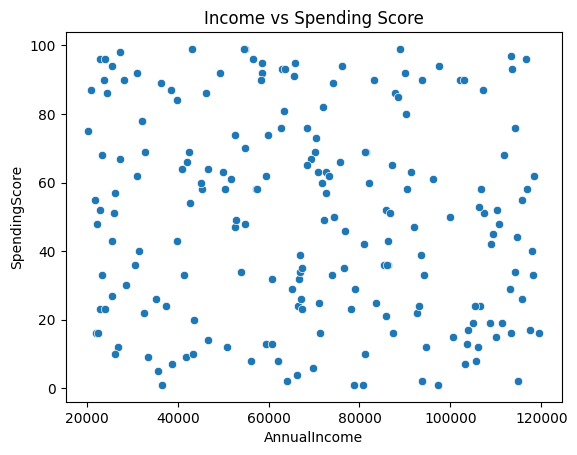

In [6]:
# Visualize relationships

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='AnnualIncome', y='SpendingScore', data=df)
plt.title("Income vs Spending Score")
plt.show()

There appears to be variation in spending behavior across different income levels, suggesting the presence of distinct customer segments.

Exploratory analysis suggests variability in customer spending behavior across different income levels, indicating the presence of distinct customer segments.

## Data Preparation

In [9]:
from sklearn.preprocessing import StandardScaler

features = df[['Age', 'AnnualIncome', 'SpendingScore']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

## Clustering (K-Means)

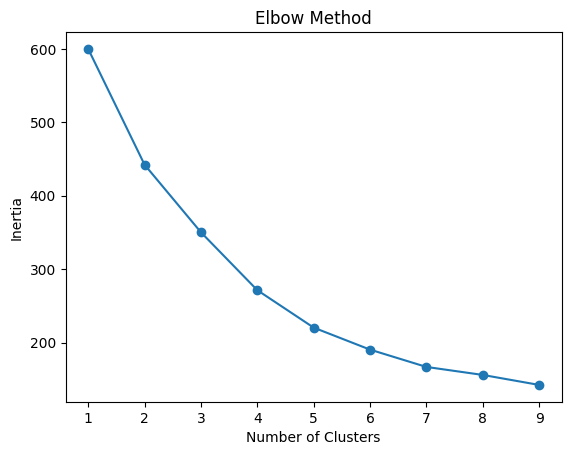

In [10]:
# Elbow Method

from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

The elbow point suggests an optimal number of clusters where adding more clusters does not significantly reduce inertia.

In [11]:
# Apply K-Means Clustering

# Assuming optimal k = 4
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,Cluster
0,1,56,78053,23,1
1,2,69,41959,66,2
2,3,46,25530,27,3
3,4,32,114856,2,1
4,5,60,23748,90,2


K-Means clustering was used to group customers based on similarity. The elbow method was applied to determine the optimal number of clusters.

## Cluster Visualization

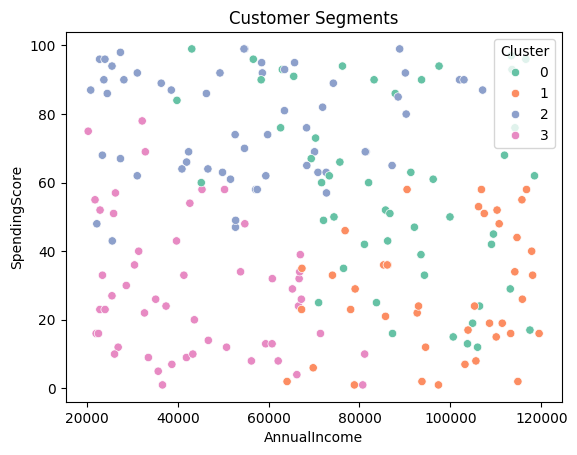

In [15]:
sns.scatterplot(
    x='AnnualIncome',
    y='SpendingScore',
    hue='Cluster',
    palette='Set2',
    data=df
)
plt.title('Customer Segments')
plt.show()

## Insights and Interpretation

In [16]:
df.groupby('Cluster').mean()

,CustomerID,Age,AnnualIncome,SpendingScore
Cluster,,,,
0,84.420000,28.040000,86924.240000,58.400000
1,103.609756,53.487805,97827.439024,27.829268
2,107.614035,55.035088,55376.666667,77.087719
3,105.711538,37.557692,43631.615385,28.442308


The clustering results reveal distinct customer groups, including high-income high-spending customers and lower-spending segments.

These insights can help businesses design targeted marketing campaigns, improve customer retention, and allocate resources more effectively.

## Conclusion

This project demonstrates how clustering techniques can be used to uncover meaningful customer segments and support data-driven business decisions.